In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sklearn
sklearn.set_config(display='text')

주성분분석(Principal Component Analysis, PCA)

차원(피쳐의 개수)을 줄이면서도 데이터가 분포된 정도(분산)는 최대한 유지되게 만들어서 고차원 데이터를 저차원 데이터로 차원을 축소하는 알고리즘을 말한다.  
주로 고차원 데이터를 3차원 이하의 데이터로 바꿔 시각화하는데 많이 사용되며, 유용한 정보만 살려서 적은 메모리에 적용하거나 노이즈(잡음)를 줄이고 싶을때도 사용되는 알고리즘이다.

<img src="./pca1.png" wigth="1300" align="left" />

<img src="./pca2.png" wigth="1300" align="left" />

<img src="./pca3.png" wigth="1300" align="left" />

<img src="./pca4.png" wigth="1300" align="left" />

적당한 데이터셋을 만든다.

In [2]:
datas = np.array([[5 * x, 5 * (np.sqrt(1 / 3) + 0.1 * np.random.normal(0, 1)) * x] for x in np.random.normal(0, 1, 30)])
print(datas)
print('=' * 100)
n_datas = datas - np.mean(datas, axis=0)
print(n_datas)

[[ 4.82596671  2.2823662 ]
 [ 2.34607496  1.30589387]
 [ 1.22363356  0.64011232]
 [-6.1199913  -2.89194713]
 [-4.05850449 -1.64685356]
 [ 0.28104599  0.15093315]
 [-3.67038147 -1.99397416]
 [ 3.45969687  2.65559253]
 [-0.39369604 -0.22517137]
 [-1.24094382 -0.84878101]
 [-1.57254616 -0.90054253]
 [-3.41547703 -2.04834064]
 [ 7.3445616   6.05395054]
 [-8.44691184 -5.1638648 ]
 [-9.44760841 -5.27315855]
 [ 3.27464731  2.12877944]
 [ 2.07823859  1.16051727]
 [-5.69153504 -3.39358497]
 [ 4.09049347  2.45948165]
 [-2.61932055 -1.58552595]
 [ 1.18024045  0.71592332]
 [ 3.37450977  1.98848613]
 [ 1.33783474  0.76944108]
 [-3.08741236 -1.86413668]
 [-0.45812484 -0.26328292]
 [ 8.7457668   4.61688991]
 [-5.14394672 -3.5403798 ]
 [-0.86163599 -0.69882347]
 [-8.59912687 -6.10639159]
 [ 4.83800424  2.78518491]]
[[ 5.37351498  2.57340642]
 [ 2.89362323  1.5969341 ]
 [ 1.77118182  0.93115255]
 [-5.57244304 -2.6009069 ]
 [-3.51095623 -1.35581334]
 [ 0.82859425  0.44197338]
 [-3.12283321 -1.70293394]


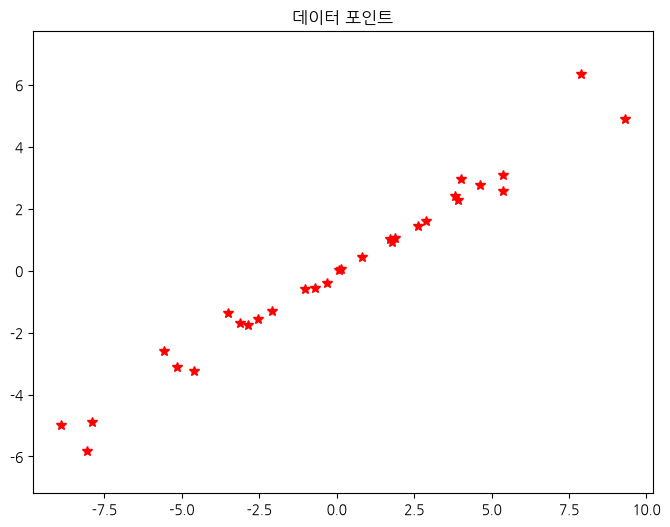

In [3]:
plt.figure(figsize=(8, 6))
plt.plot(n_datas[:, 0], n_datas[:, 1], '*r', markersize=7)
plt.title('데이터 포인트')
plt.axis('equal') # 각 축의 범위와 스케일을 동일하게 설정한다.
plt.show()

행렬 내적

In [4]:
A = np.array([[1, 2], [3, 4]])
print('A\n', A, sep='')
B = np.array([[1, -2], [2, 3]])
print('B\n', B, sep='')
print('=' * 100)
print('AB\n', np.dot(A, B), sep='')
print('AB\n', np.matmul(A, B), sep='')
print('AB\n', A @ B, sep='') # @ => numpy의 행렬 내적 연산자

A
[[1 2]
 [3 4]]
B
[[ 1 -2]
 [ 2  3]]
AB
[[ 5  4]
 [11  6]]
AB
[[ 5  4]
 [11  6]]
AB
[[ 5  4]
 [11  6]]


벡터 내적

x축으로 사영하면 y좌표는 무시되고 x좌표만 남는다.

In [5]:
# 벡터를 1행 2열로 만든다. => 1행만 있으므로 행 벡터이다.
# print(np.array([1, 0]))
# 30행 2열인 2차원 배열(n_datas)을 행 벡터 [1, 0]와 내적하면 결과는 데이터가 30인 1차원 배열이 된다.
proj1_x = n_datas @ np.array([1, 0])
# print(proj1_x)
# reshape(-1, n)는 행 개수는 상황에 따라 적절히 만들고 열 개수를 n개로 고정한다.
# 데이터가 30개인 1차원 배열에 reshape(-1, 1)를 실행하면 30행 1열인 2차원 배열이 된다.
# print(proj1_x.reshape(-1, 1))
proj2_x = proj1_x.reshape(-1, 1) @ np.array([[1, 0]])
print(proj2_x)

[[ 5.37351498  0.        ]
 [ 2.89362323  0.        ]
 [ 1.77118182  0.        ]
 [-5.57244304  0.        ]
 [-3.51095623  0.        ]
 [ 0.82859425  0.        ]
 [-3.12283321  0.        ]
 [ 4.00724513  0.        ]
 [ 0.15385222  0.        ]
 [-0.69339556  0.        ]
 [-1.0249979   0.        ]
 [-2.86792877  0.        ]
 [ 7.89210986  0.        ]
 [-7.89936358  0.        ]
 [-8.90006015  0.        ]
 [ 3.82219558  0.        ]
 [ 2.62578685  0.        ]
 [-5.14398678  0.        ]
 [ 4.63804173  0.        ]
 [-2.07177229  0.        ]
 [ 1.72778871  0.        ]
 [ 3.92205803  0.        ]
 [ 1.88538301  0.        ]
 [-2.5398641   0.        ]
 [ 0.08942342  0.        ]
 [ 9.29331506  0.        ]
 [-4.59639846  0.        ]
 [-0.31408773  0.        ]
 [-8.0515786   0.        ]
 [ 5.3855525   0.        ]]


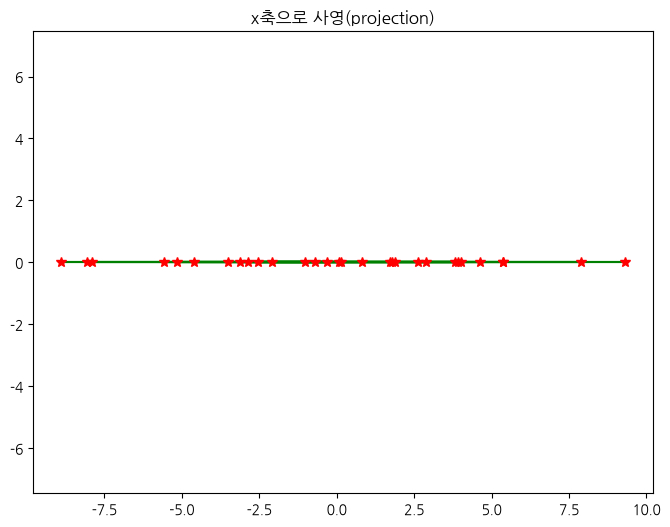

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_x[:, 0], proj2_x[:, 1], 'g')
plt.plot(proj2_x[:, 0], proj2_x[:, 1], '*r', markersize=7)
plt.title('x축으로 사영(projection)')
plt.axis('equal')
plt.show()

In [7]:
# 벡터를 1행 2열로 만들어서 reshape() 메소드로 2행 1열로 변환한다. => 1열만 있으므로 열 벡터이다.
# print(np.array([1, 0]).reshape(2, 1))
proj1_x = n_datas @ np.array([1, 0]).reshape(2, 1)
# print(proj1_x)
proj2_x = proj1_x @ np.array([[1, 0]])
print(proj2_x)

[[ 5.37351498  0.        ]
 [ 2.89362323  0.        ]
 [ 1.77118182  0.        ]
 [-5.57244304  0.        ]
 [-3.51095623  0.        ]
 [ 0.82859425  0.        ]
 [-3.12283321  0.        ]
 [ 4.00724513  0.        ]
 [ 0.15385222  0.        ]
 [-0.69339556  0.        ]
 [-1.0249979   0.        ]
 [-2.86792877  0.        ]
 [ 7.89210986  0.        ]
 [-7.89936358  0.        ]
 [-8.90006015  0.        ]
 [ 3.82219558  0.        ]
 [ 2.62578685  0.        ]
 [-5.14398678  0.        ]
 [ 4.63804173  0.        ]
 [-2.07177229  0.        ]
 [ 1.72778871  0.        ]
 [ 3.92205803  0.        ]
 [ 1.88538301  0.        ]
 [-2.5398641   0.        ]
 [ 0.08942342  0.        ]
 [ 9.29331506  0.        ]
 [-4.59639846  0.        ]
 [-0.31408773  0.        ]
 [-8.0515786   0.        ]
 [ 5.3855525   0.        ]]


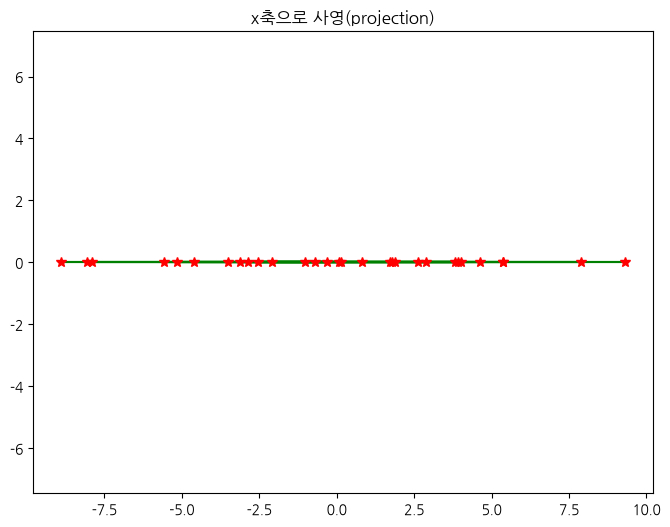

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_x[:, 0], proj2_x[:, 1], 'g')
plt.plot(proj2_x[:, 0], proj2_x[:, 1], '*r', markersize=7)
plt.title('x축으로 사영(projection)')
plt.axis('equal')
plt.show()

In [9]:
# 벡터를 2행 1열로 만든다. => 1열만 있으므로 열 벡터이다.
# print(np.array([[1], [0]]))
proj1_x = n_datas @ np.array([[1], [0]])
# print(proj1)
proj2_x = proj1_x @ np.array([[1, 0]])
print(proj2_x)

[[ 5.37351498  0.        ]
 [ 2.89362323  0.        ]
 [ 1.77118182  0.        ]
 [-5.57244304  0.        ]
 [-3.51095623  0.        ]
 [ 0.82859425  0.        ]
 [-3.12283321  0.        ]
 [ 4.00724513  0.        ]
 [ 0.15385222  0.        ]
 [-0.69339556  0.        ]
 [-1.0249979   0.        ]
 [-2.86792877  0.        ]
 [ 7.89210986  0.        ]
 [-7.89936358  0.        ]
 [-8.90006015  0.        ]
 [ 3.82219558  0.        ]
 [ 2.62578685  0.        ]
 [-5.14398678  0.        ]
 [ 4.63804173  0.        ]
 [-2.07177229  0.        ]
 [ 1.72778871  0.        ]
 [ 3.92205803  0.        ]
 [ 1.88538301  0.        ]
 [-2.5398641   0.        ]
 [ 0.08942342  0.        ]
 [ 9.29331506  0.        ]
 [-4.59639846  0.        ]
 [-0.31408773  0.        ]
 [-8.0515786   0.        ]
 [ 5.3855525   0.        ]]


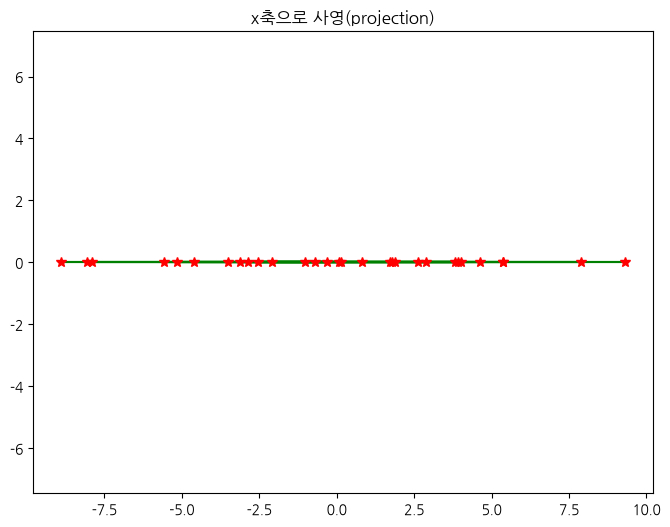

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_x[:, 0], proj2_x[:, 1], 'g')
plt.plot(proj2_x[:, 0], proj2_x[:, 1], '*r', markersize=7)
plt.title('x축으로 사영(projection)')
plt.axis('equal')
plt.show()

y축으로 사영하면 x좌표는 무시되고 y좌표만 남는다.

In [11]:
proj1_y = n_datas @ np.array([0, 1])
proj2_y = proj1_y.reshape(-1, 1) @ np.array([[0, 1]])
print(proj2_y)

[[ 0.          2.57340642]
 [ 0.          1.5969341 ]
 [ 0.          0.93115255]
 [ 0.         -2.6009069 ]
 [ 0.         -1.35581334]
 [ 0.          0.44197338]
 [ 0.         -1.70293394]
 [ 0.          2.94663276]
 [ 0.          0.06586886]
 [ 0.         -0.55774078]
 [ 0.         -0.6095023 ]
 [ 0.         -1.75730041]
 [ 0.          6.34499076]
 [ 0.         -4.87282458]
 [ 0.         -4.98211833]
 [ 0.          2.41981967]
 [ 0.          1.4515575 ]
 [ 0.         -3.10254474]
 [ 0.          2.75052188]
 [ 0.         -1.29448572]
 [ 0.          1.00696355]
 [ 0.          2.27952636]
 [ 0.          1.06048131]
 [ 0.         -1.57309646]
 [ 0.          0.0277573 ]
 [ 0.          4.90793014]
 [ 0.         -3.24933957]
 [ 0.         -0.40778324]
 [ 0.         -5.81535137]
 [ 0.          3.07622514]]


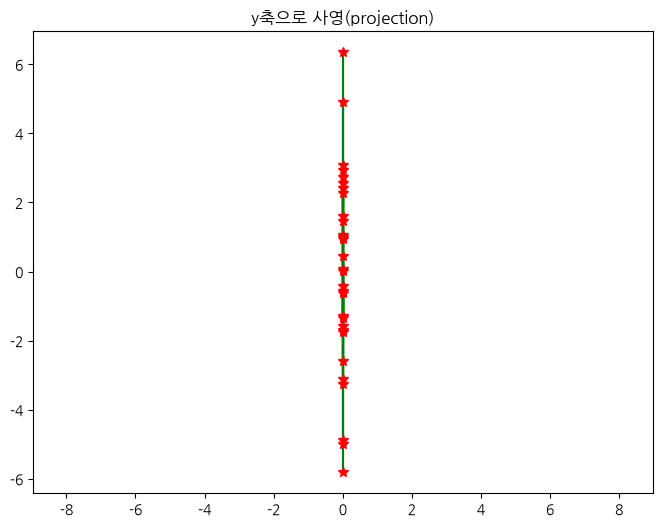

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_y[:, 0], proj2_y[:, 1], 'g')
plt.plot(proj2_y[:, 0], proj2_y[:, 1], '*r', markersize=7)
plt.title('y축으로 사영(projection)')
plt.axis('equal')
plt.show()

In [13]:
proj1_y = n_datas @ np.array([0, 1]).reshape(2, 1)
proj2_y = proj1_y @ np.array([[0, 1]])
print(proj2_y)

[[ 0.          2.57340642]
 [ 0.          1.5969341 ]
 [ 0.          0.93115255]
 [ 0.         -2.6009069 ]
 [ 0.         -1.35581334]
 [ 0.          0.44197338]
 [ 0.         -1.70293394]
 [ 0.          2.94663276]
 [ 0.          0.06586886]
 [ 0.         -0.55774078]
 [ 0.         -0.6095023 ]
 [ 0.         -1.75730041]
 [ 0.          6.34499076]
 [ 0.         -4.87282458]
 [ 0.         -4.98211833]
 [ 0.          2.41981967]
 [ 0.          1.4515575 ]
 [ 0.         -3.10254474]
 [ 0.          2.75052188]
 [ 0.         -1.29448572]
 [ 0.          1.00696355]
 [ 0.          2.27952636]
 [ 0.          1.06048131]
 [ 0.         -1.57309646]
 [ 0.          0.0277573 ]
 [ 0.          4.90793014]
 [ 0.         -3.24933957]
 [ 0.         -0.40778324]
 [ 0.         -5.81535137]
 [ 0.          3.07622514]]


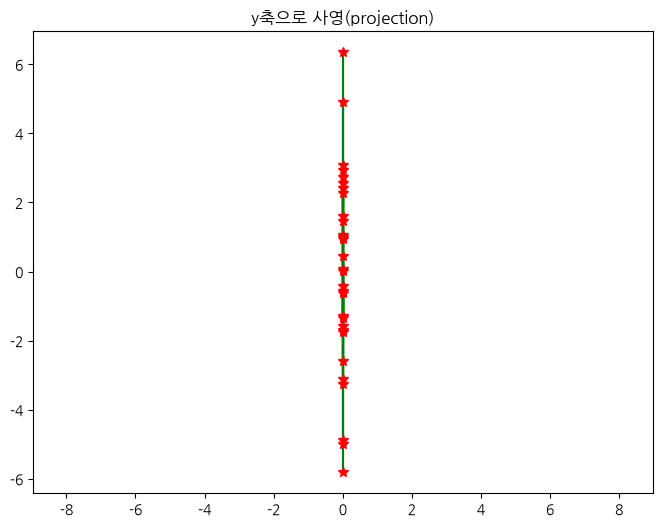

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_y[:, 0], proj2_y[:, 1], 'g')
plt.plot(proj2_y[:, 0], proj2_y[:, 1], '*r', markersize=7)
plt.title('y축으로 사영(projection)')
plt.axis('equal')
plt.show()

In [15]:
proj1_y = n_datas @ np.array([[0], [1]])
proj2_y = proj1_y @ np.array([[0, 1]])
print(proj2_y)

[[ 0.          2.57340642]
 [ 0.          1.5969341 ]
 [ 0.          0.93115255]
 [ 0.         -2.6009069 ]
 [ 0.         -1.35581334]
 [ 0.          0.44197338]
 [ 0.         -1.70293394]
 [ 0.          2.94663276]
 [ 0.          0.06586886]
 [ 0.         -0.55774078]
 [ 0.         -0.6095023 ]
 [ 0.         -1.75730041]
 [ 0.          6.34499076]
 [ 0.         -4.87282458]
 [ 0.         -4.98211833]
 [ 0.          2.41981967]
 [ 0.          1.4515575 ]
 [ 0.         -3.10254474]
 [ 0.          2.75052188]
 [ 0.         -1.29448572]
 [ 0.          1.00696355]
 [ 0.          2.27952636]
 [ 0.          1.06048131]
 [ 0.         -1.57309646]
 [ 0.          0.0277573 ]
 [ 0.          4.90793014]
 [ 0.         -3.24933957]
 [ 0.         -0.40778324]
 [ 0.         -5.81535137]
 [ 0.          3.07622514]]


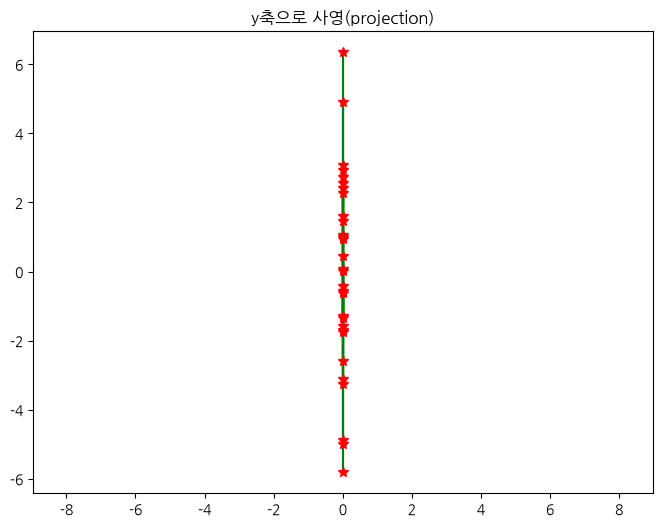

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(proj2_y[:, 0], proj2_y[:, 1], 'g')
plt.plot(proj2_y[:, 0], proj2_y[:, 1], '*r', markersize=7)
plt.title('y축으로 사영(projection)')
plt.axis('equal')
plt.show()

데이터를 임의로 설정한 선 위로 사영한다.

In [17]:
# print(np.array([np.cos(np.pi / 6), np.sin(np.pi / 6)]))
proj1 = n_datas @ np.array([np.cos(np.pi / 6), np.sin(np.pi / 6)])
# print(proj1)
proj2 = proj1.reshape(-1, 1) @ np.array([[np.cos(np.pi / 6), np.sin(np.pi / 6)]])
print(proj2)

[[ 5.1444539   2.97015185]
 [ 2.86171017  1.65220914]
 [ 1.73158725  0.99973236]
 [-5.305558   -3.06316534]
 [-3.22030157 -1.85924198]
 [ 0.81282578  0.46928518]
 [-3.07951693 -1.77795993]
 [ 4.28136326  2.47184623]
 [ 0.14391122  0.08308718]
 [-0.76155552 -0.43968428]
 [-1.03267066 -0.59621269]
 [-2.91187998 -1.68117469]
 [ 8.66654399  5.00363151]
 [-8.03451762 -4.63873091]
 [-8.83236563 -5.09936867]
 [ 3.91445933  2.26001415]
 [ 2.59788297  1.49988843]
 [-5.20143136 -3.0030478 ]
 [ 4.66954221  2.69596145]
 [-2.11435798 -1.22072515]
 [ 1.73186954  0.99989535]
 [ 3.92860739  2.26818253]
 [ 1.87323913  1.08151512]
 [-2.58606882 -1.49306753]
 [ 0.07908683  0.0456608 ]
 [ 9.09518239  5.251106  ]
 [-4.85430415 -2.80263381]
 [-0.41214112 -0.23794979]
 [-8.55680496 -4.94027365]
 [ 5.37120894  3.10106893]]


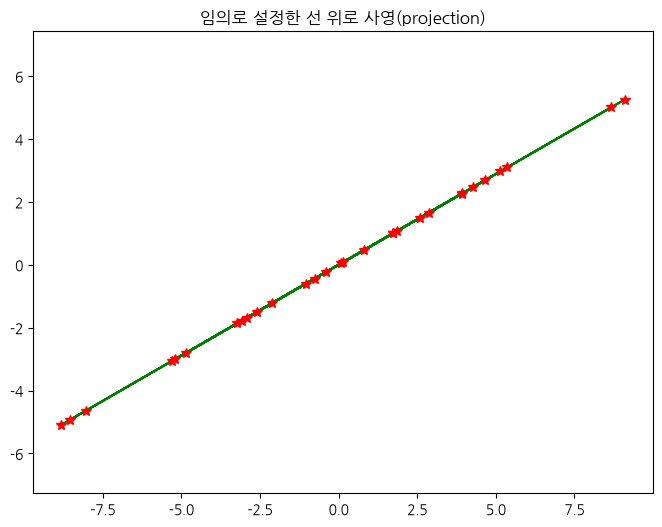

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(proj2[:, 0], proj2[:, 1], 'g')
plt.plot(proj2[:, 0], proj2[:, 1], '*r', markersize=7)
plt.title('임의로 설정한 선 위로 사영(projection)')
plt.axis('equal')
plt.show()

In [19]:
proj1 = n_datas @ np.array([np.cos(np.pi / 6), np.sin(np.pi / 6)]).reshape(2, 1)
proj2 = proj1 @ np.array([[np.cos(np.pi / 6), np.sin(np.pi / 6)]])
print(proj2)

[[ 5.1444539   2.97015185]
 [ 2.86171017  1.65220914]
 [ 1.73158725  0.99973236]
 [-5.305558   -3.06316534]
 [-3.22030157 -1.85924198]
 [ 0.81282578  0.46928518]
 [-3.07951693 -1.77795993]
 [ 4.28136326  2.47184623]
 [ 0.14391122  0.08308718]
 [-0.76155552 -0.43968428]
 [-1.03267066 -0.59621269]
 [-2.91187998 -1.68117469]
 [ 8.66654399  5.00363151]
 [-8.03451762 -4.63873091]
 [-8.83236563 -5.09936867]
 [ 3.91445933  2.26001415]
 [ 2.59788297  1.49988843]
 [-5.20143136 -3.0030478 ]
 [ 4.66954221  2.69596145]
 [-2.11435798 -1.22072515]
 [ 1.73186954  0.99989535]
 [ 3.92860739  2.26818253]
 [ 1.87323913  1.08151512]
 [-2.58606882 -1.49306753]
 [ 0.07908683  0.0456608 ]
 [ 9.09518239  5.251106  ]
 [-4.85430415 -2.80263381]
 [-0.41214112 -0.23794979]
 [-8.55680496 -4.94027365]
 [ 5.37120894  3.10106893]]


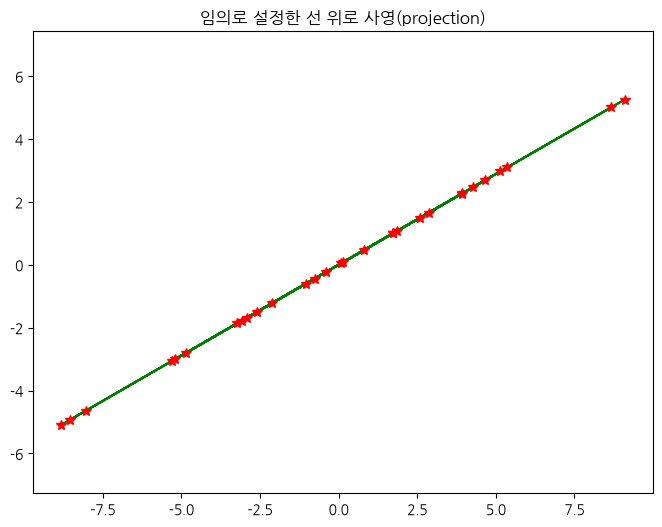

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(proj2[:, 0], proj2[:, 1], 'g')
plt.plot(proj2[:, 0], proj2[:, 1], '*r', markersize=7)
plt.title('임의로 설정한 선 위로 사영(projection)')
plt.axis('equal')
plt.show()

In [21]:
proj1 = n_datas @ np.array([[np.cos(np.pi / 6)], [np.sin(np.pi / 6)]])
proj2 = proj1 @ np.array([[np.cos(np.pi / 6), np.sin(np.pi / 6)]])
print(proj2)

[[ 5.1444539   2.97015185]
 [ 2.86171017  1.65220914]
 [ 1.73158725  0.99973236]
 [-5.305558   -3.06316534]
 [-3.22030157 -1.85924198]
 [ 0.81282578  0.46928518]
 [-3.07951693 -1.77795993]
 [ 4.28136326  2.47184623]
 [ 0.14391122  0.08308718]
 [-0.76155552 -0.43968428]
 [-1.03267066 -0.59621269]
 [-2.91187998 -1.68117469]
 [ 8.66654399  5.00363151]
 [-8.03451762 -4.63873091]
 [-8.83236563 -5.09936867]
 [ 3.91445933  2.26001415]
 [ 2.59788297  1.49988843]
 [-5.20143136 -3.0030478 ]
 [ 4.66954221  2.69596145]
 [-2.11435798 -1.22072515]
 [ 1.73186954  0.99989535]
 [ 3.92860739  2.26818253]
 [ 1.87323913  1.08151512]
 [-2.58606882 -1.49306753]
 [ 0.07908683  0.0456608 ]
 [ 9.09518239  5.251106  ]
 [-4.85430415 -2.80263381]
 [-0.41214112 -0.23794979]
 [-8.55680496 -4.94027365]
 [ 5.37120894  3.10106893]]


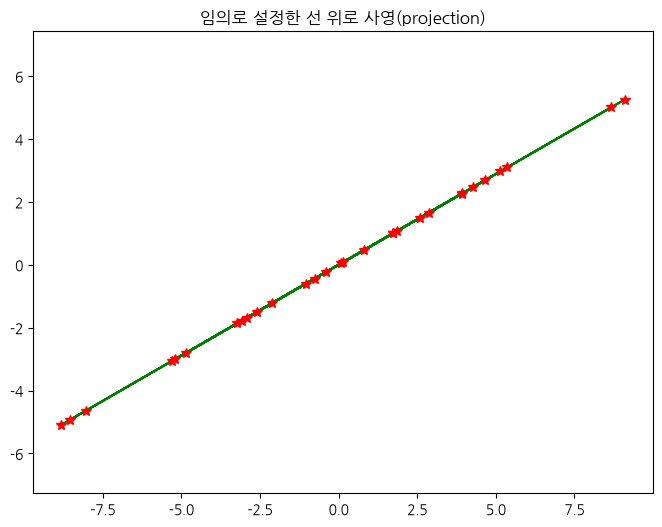

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(proj2[:, 0], proj2[:, 1], 'g')
plt.plot(proj2[:, 0], proj2[:, 1], '*r', markersize=7)
plt.title('임의로 설정한 선 위로 사영(projection)')
plt.axis('equal')
plt.show()

표준편차가 큰게 데이터 과학 입장에서는 데이터의 분포를 잘 보존하고 있다고 생각할 수 있다.  
임의로 설정한 선의 표준편차가 가장 크므로 x축이나 y축 보다는 임의의 선으로 정사영하는 것이 좋다.

In [23]:
print(np.std(proj1_x)) # x축 위로 사영
print(np.std(proj1_y)) # y축 위로 사영
print(np.std(proj1)) # 임의로 설정한 선 위로 사영

4.573510064983603
2.8151601531833212
5.354248841255573


공분산(Covariance)

두 집단의 상호 연관성(상관 관계)을 측정하는 도구로 $X$에서 $X$의 기대값(평균)을 뺀 편차에서 $Y$에서 $Y$의 기대값을 뺀 편차의 곱에 대한 기대값으로 계산한다.

$$cov=E((X-E(X))(Y-E(Y)))$$

$x=\{x_1, x_2, \ldots, x_n\}$이고 $y=\{y_1, y_2, \ldots, y_n\}$일 때 $x$와 $y$의 공분산은 아래와 같이 계산한다.

$$cov=\frac{1}{n-1} \sum_{i=1}^{n}(x_i-\bar x)(y_i-\bar y)$$

분모를 $n-1$로 계산하는 이유는 표본에 대한 공분산이기 때문이다. 만약에 모집단 전체에 대해서 공분산을 계산할 때는 $n$으로 계산한다.

$Z = \begin{bmatrix} x_1 & x_2 & \cdots x_n \\ y_1 & y_2 & \cdots y_n \end{bmatrix}$ 이고  $\bar x = \bar y=0$일 경우 공분산 행렬은 $\Sigma =\begin{bmatrix} {\rm Var}(x) & {\rm Cov}(x,y) \\ {\rm Cov}(y,x) & {\rm Var}(y) \end{bmatrix}$와 같이 계산할 수 있고 $ ZZ^T = \begin{bmatrix} \langle x, x\rangle  &\langle x, y \rangle \\ \langle y, x \rangle &\langle y, y \rangle \end{bmatrix}$와 비례한다.

In [32]:
# 공분산 행렬을 계산한다.
print((n_datas.T @ n_datas) / 29)
# ddof(delta degrees of freedom, 자유도)는 생략시 0이고 n으로 나누는것이고, 1은 (n-1)로 나누는 것이다. 표본분산
print(np.var(n_datas[:, 0], ddof=1))
print(np.var(n_datas[:, 1], ddof=1))
# numpy의 cov() 메소드로 공분산 행렬을 계산할 수 있다.
print(np.cov(n_datas.T, ddof=1))

[[21.63826998 13.13844542]
 [13.13844542  8.19840692]]
21.63826998052378
8.198406918694284
[[21.63826998 13.13844542]
 [13.13844542  8.19840692]]


PCA 예제1

In [36]:
sigma = np.cov(n_datas.T, ddof=1) # 공분산 행렬
# print(sigma)
# numpy의 linalg.eig() 메소드는 공분산 행렬을 인수로 넘겨받아 고유값과 고유 벡터로 이루어진 행렬을 계산해서 리턴한다.
las, evs = np.linalg.eig(sigma)
print(las) # 고유값, 피쳐가 2개이기 때문에 고유값이 2개 나온다.
# 고유 벡터 행렬의 첫 번째 열 벡터가 첫 번째 고유값에 대응되고 두 번째 열 벡터가 두 번째 고유값에 대응된다.
# 원래(n_datas) 특성의 x값에 열 벡터의 첫 번째 값을 내적하고 y값에 열 벡터의 두 번째 값을 내적한 특성을 새로운 특성으로 사용하면 데이터의 분포를 거의 
# 유지하면서 1차원으로 데이터를 나타낼 수 있다는 의미이다.
print(evs) # 고유 벡터 행렬

[29.67558168  0.16109522]
[[ 0.85304307 -0.52184051]
 [ 0.52184051  0.85304307]]


In [40]:
proj1_pca1_x = evs[:, 0] # 첫 번째 특성 벡터, x축
print(proj1_pca1_x)
proj2_pca1_x = n_datas @ proj1_pca1_x
print(proj2_pca1_x)

[0.85304307 0.52184051]
[  5.92674744   3.30173015   1.9968075   -6.11079251  -3.70251521
   0.9374662   -3.55257115   4.95602504   0.16561561  -0.88254802
  -1.19243035  -3.36349731  10.04338285  -9.28133463 -10.19200581
   4.52325738   2.99739079  -6.00707581   5.39178311  -2.44282609
   1.99935256   4.53523363   2.16171502  -2.98751893   0.09076692
  10.48875479  -5.61656288  -0.48072818  -9.90302927   6.19940715]


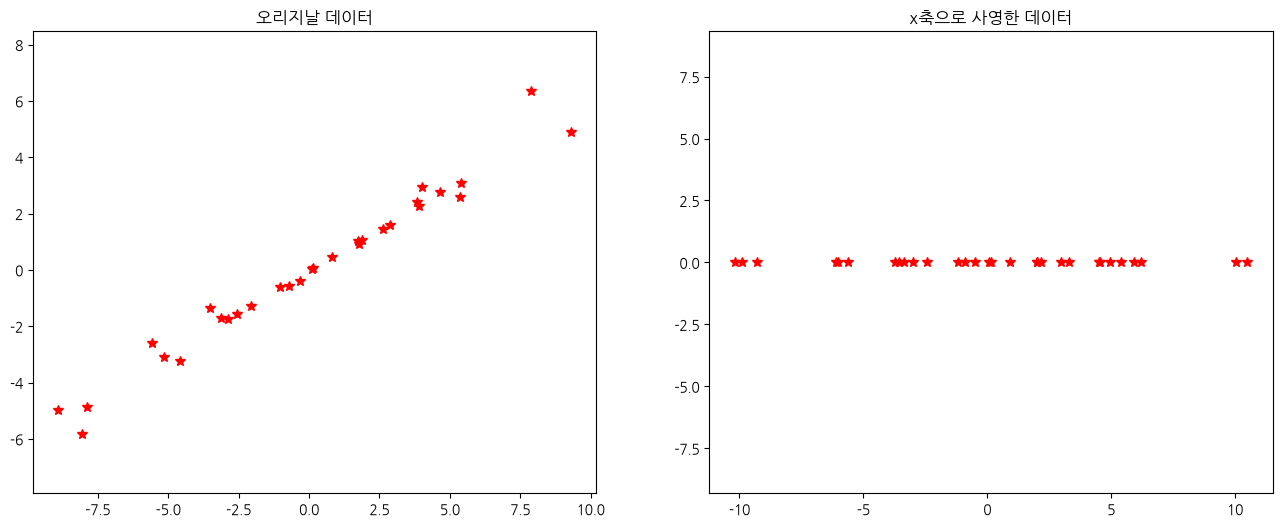

In [43]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(n_datas[:, 0], n_datas[:, 1], '*r', markersize=7)
plt.title('오리지날 데이터')
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.plot(proj2_pca1_x, np.zeros_like(proj2_pca1_x), '*r', markersize=7)
plt.title('x축으로 사영한 데이터')
plt.axis('equal')

plt.show()

In [44]:
proj1_pca1_y = evs[:, 1] # 두 번째 특성 벡터, y축
print(proj1_pca1_y)
proj2_pca1_y = n_datas @ proj1_pca1_y
print(proj2_pca1_y)

[-0.52184051  0.85304307]
[-0.60889128 -0.14775625 -0.12996119  0.68924091  0.67559202 -0.05537172
  0.17694488  0.42246182 -0.02409735 -0.11393502  0.01495371 -0.00245153
  1.29412777 -0.03452132  0.39445041  0.06963391 -0.13200089  0.03773638
 -0.07400443 -0.02311736 -0.04264687 -0.1021546  -0.07923299 -0.01651506
 -0.02298659 -0.66295247 -0.37323969 -0.18395297 -0.75910531 -0.18624692]


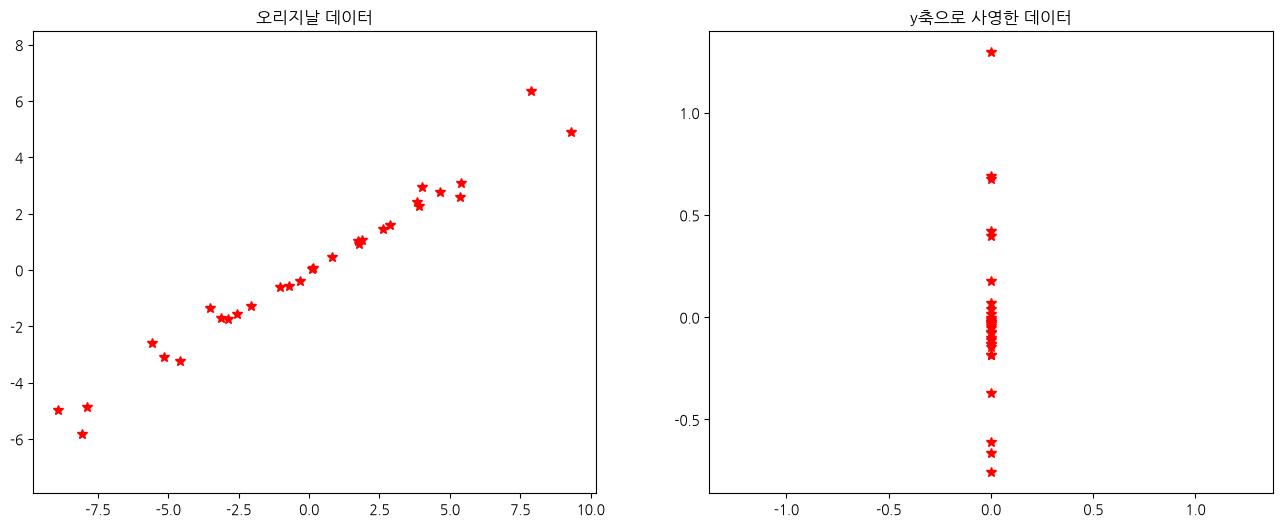

In [47]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(n_datas[:, 0], n_datas[:, 1], '*r', markersize=7)
plt.title('오리지날 데이터')
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.plot(np.zeros_like(proj2_pca1_y), proj2_pca1_y, '*r', markersize=7)
plt.title('y축으로 사영한 데이터')
plt.axis('equal')

plt.show()

In [50]:
print(np.std(proj1)) # 임의로 설정한 선 위로 사영
print(np.std(proj1_pca1_x))
print(np.std(proj1_pca1_y))

5.354248841255573
0.16560128072029145
0.6874417908621785


PCA 예제2

In [52]:
from sklearn.datasets import load_digits
dataset = load_digits()
print(dataset.data.shape)

(1797, 64)


In [55]:
print(dataset.data[0])
print(dataset.data[0].reshape(8, 8))

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
0


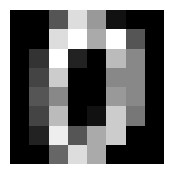

target value: 0


In [66]:
plt.figure(figsize=[2, 2])
plt.imshow(dataset.data[0].reshape(8, 8), cmap=plt.cm.gray)
plt.axis('off')
plt.show()
print(f'target value: {dataset.target[0]}')

In [78]:
X = dataset.data.copy()
X = X.T # 행렬을 전치하여 각 특징 벡터를 열 벡터로 만든다.
X = X - np.mean(X, axis=1).reshape(-1, 1) # 브로드캐스팅을 이용해 평균이 0이 되도록 해서 중심을 맞춘다.
sigma = X @ X.T # 공분산 행렬을 계산한다.
las, evs = np.linalg.eig(sigma)
print(len(las))
print(las[:6])
# 처음 고유값 2개를 더한 값이 전체 고유값의 합계 중에서 28.5%를 차지하므로 피쳐를 2개만 사용하더라도 전체 데이터의 분산을 28.5% 보존하고 있음을 알 수 있다.
print(sum(las[:2]) / sum(las))
print(evs[:2])

64
[321496.44645596 294037.07339949 254652.03660974 181576.27386432
 124845.64540141 106158.9106958 ]
0.2850936482369927
[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.          0.        ]
 [ 0.01730947  0.01010646 -0.01834207  0.02001291 -0.01407859 -0.00963006
  -0.00248955 -0.02264646  0.01697834  0.02487613  0.00247268 -0.00694806
   0.02681175 -0.052

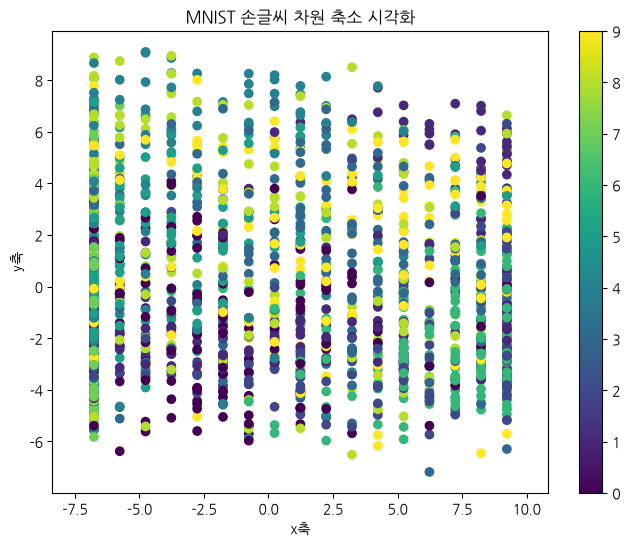

In [81]:
first_components = evs[0] @ X
second_components = evs[1] @ X

plt.figure(figsize=(8, 6))
plt.scatter(first_components, second_components, c=dataset.target)
plt.title('MNIST 손글씨 차원 축소 시각화')
plt.xlabel('x축')
plt.ylabel('y축')
plt.axis('equal')
plt.colorbar()
plt.show()